# **                                        *KNN* **

# Tasks:

1. Analyse the data using the visualizations
2. Preprocess the data by handling missing values & Outliers, if any.
3. Split the dataset into training and testing sets (80% training, 20% testing).
4. Implement the K-Nearest Neighbours algorithm using a machine learning library like scikit-learn On training dataset
5. Choose an appropriate distance metric and value for K.
6. Evaluate the classifier's performance on the testing set using accuracy, precision, recall, and F1-score metrics.
7. Visualize the decision boundaries of the classifier.


In [32]:
import numpy as np
import pandas as pd

In [33]:
df=pd.read_csv('Zoo.csv')

In [34]:
df

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [35]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

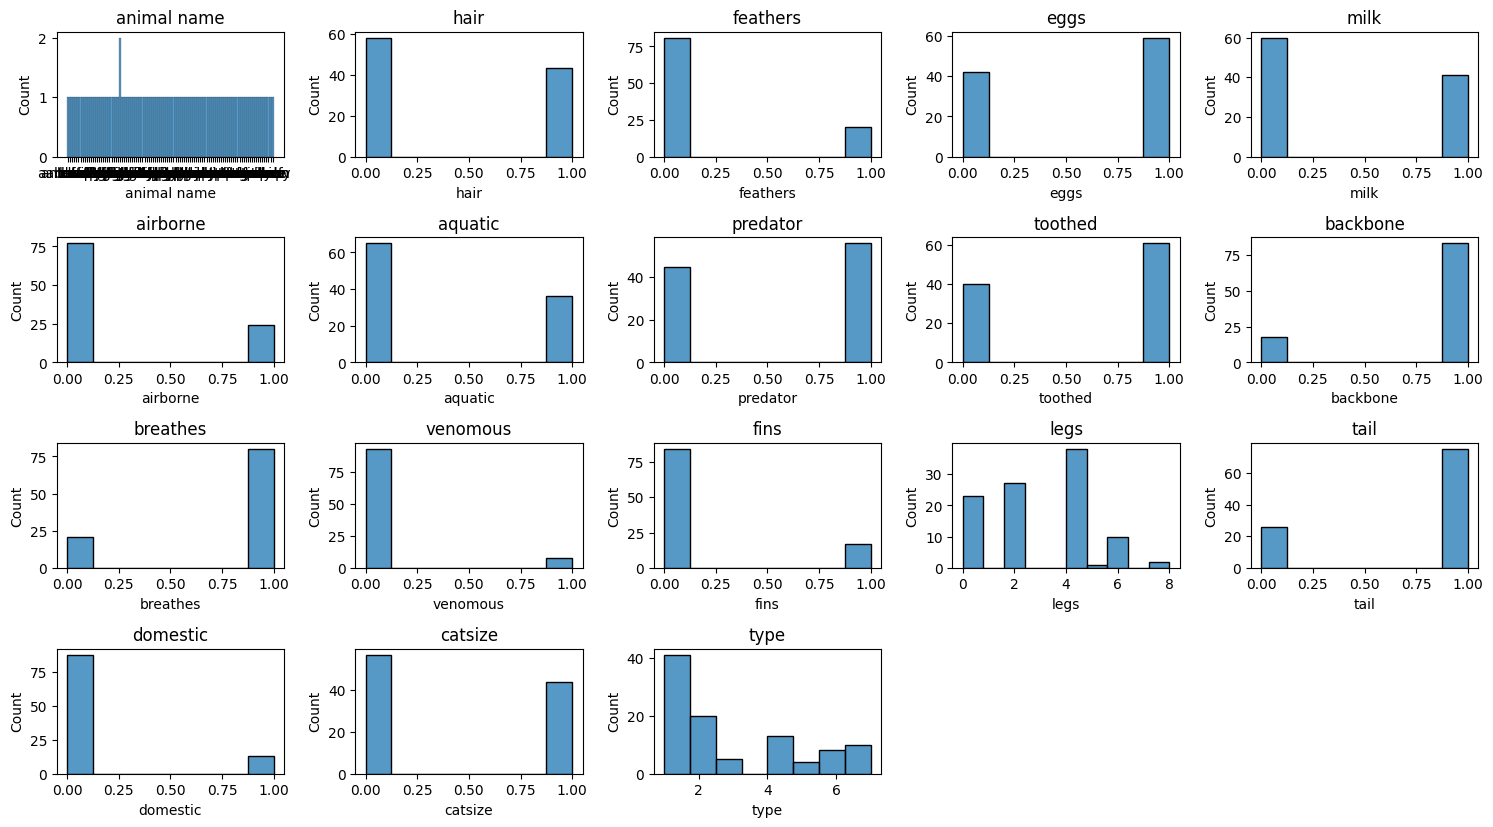

In [37]:
plt.figure(figsize=(15,10))
for i,col in enumerate(df.columns):
    plt.subplot(5,5,i+1)
    sns.histplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

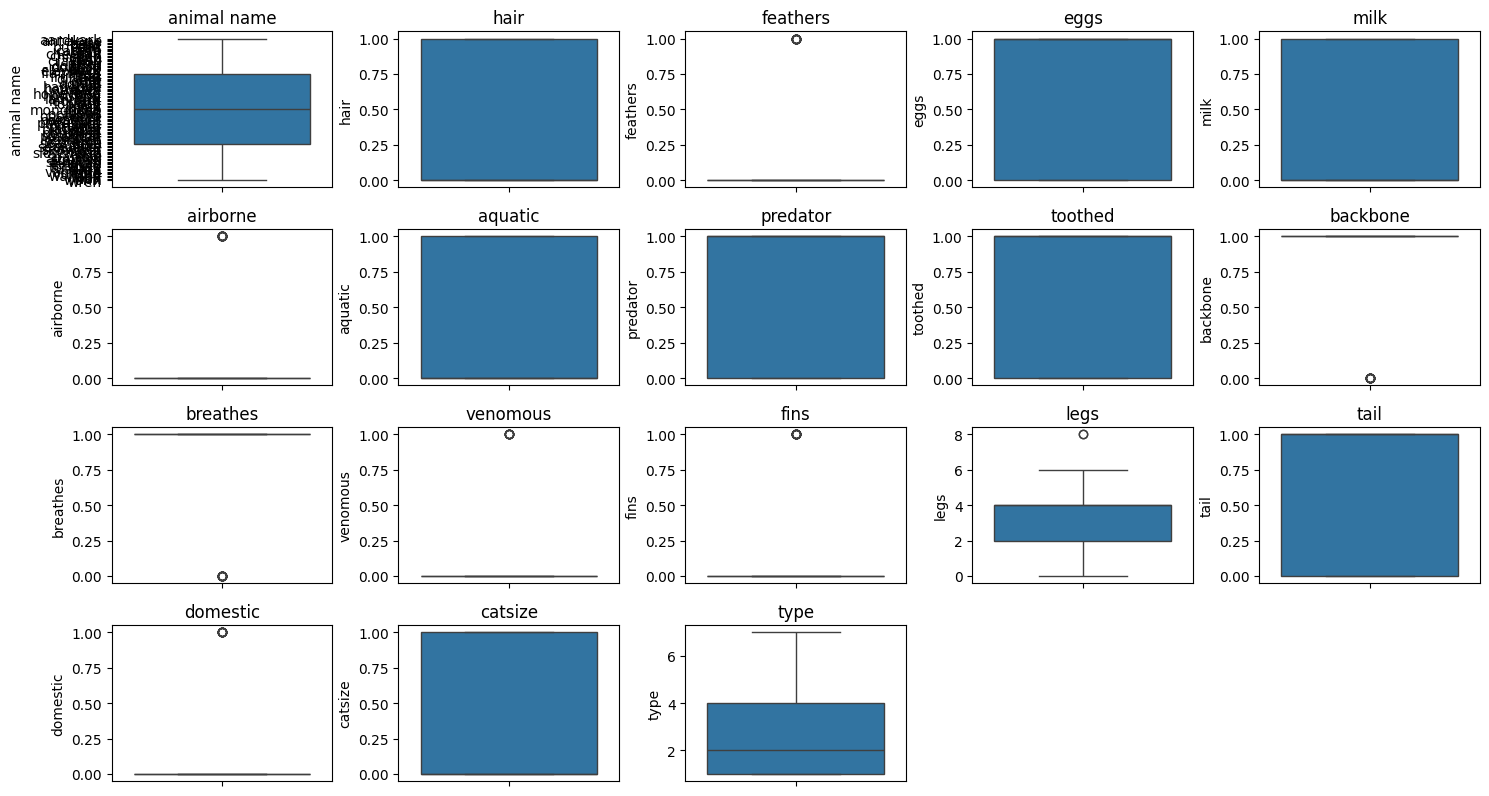

In [38]:
plt.figure(figsize=(15,10))
for i,col in enumerate(df.columns):
    plt.subplot(5,5,i+1)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [39]:
Q1 = df['legs'].quantile(0.25)
Q3 = df['legs'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df['legs'] = np.where(df['legs'] < lower_bound, lower_bound, df['legs'])
df['legs'] = np.where(df['legs'] > upper_bound, upper_bound, df['legs'])

print(f"Outliers in 'legs' column handled. Values below {lower_bound} were capped at {lower_bound}, and values above {upper_bound} were capped at {upper_bound}.")


display(df['legs'].describe())

Outliers in 'legs' column handled. Values below -1.0 were capped at -1.0, and values above 7.0 were capped at 7.0.


,legs
count,101.000000
mean,2.821782
std,1.986938
min,0.000000
25%,2.000000
50%,4.000000
75%,4.000000
max,7.000000


**missing values **

In [40]:
df.isnull().sum()

,0
animal name,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0


droping 'type' & 'animal name' for Train_test_spliting

In [41]:
x=df.drop(['type', 'animal name'],axis=1)
y=df['type']

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [43]:
print('x_train:',x_train.shape)
print('x_test:',x_test.shape)
print('y_train:',y_train.shape)
print('y_test:',y_test.shape)

x_train: (80, 16)
x_test: (21, 16)
y_train: (80,)
y_test: (21,)


trained data fiting to KNN Classifier model

In [44]:
from sklearn.neighbors import KNeighborsClassifier

In [45]:
knn_model = KNeighborsClassifier(n_neighbors=5)


In [46]:
knn_model.fit(x_train, y_train)


KNeighborsClassifier()

In [47]:
y_pred = knn_model.predict(x_test)
y_pred

array([1, 1, 4, 1, 1, 6, 1, 1, 1, 1, 4, 6, 6, 2, 7, 1, 1, 2, 4, 1, 4])

**finding accuracy,f1,precision,recall,score**

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)


print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.9048
Precision: 0.9048
Recall: 0.9048
F1-Score: 0.8958


**DESICION REGIONS PLOTTING**

In [49]:
#installing mlxtend for better region plot
%pip install mlxtend

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


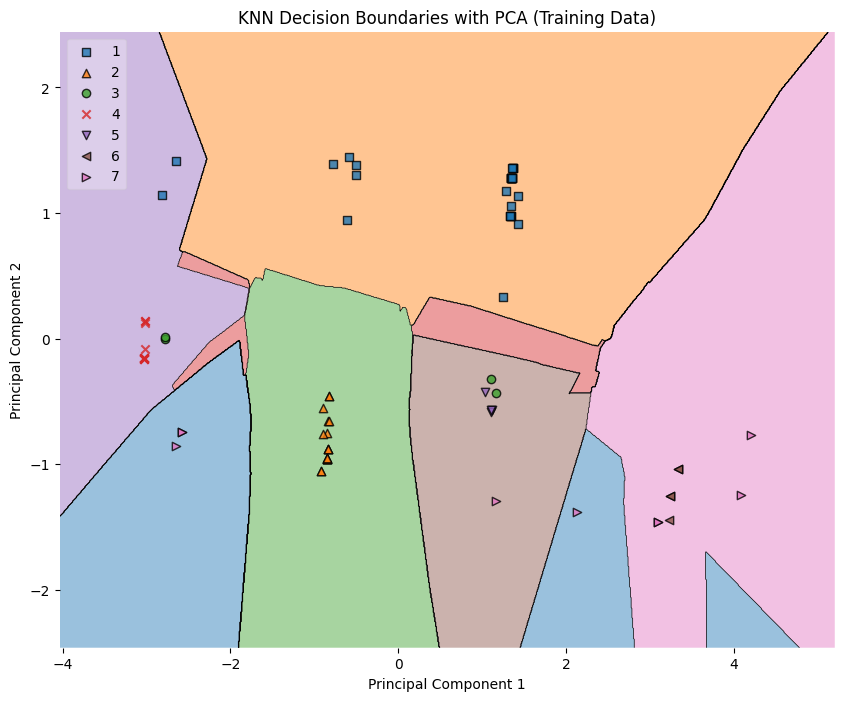

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


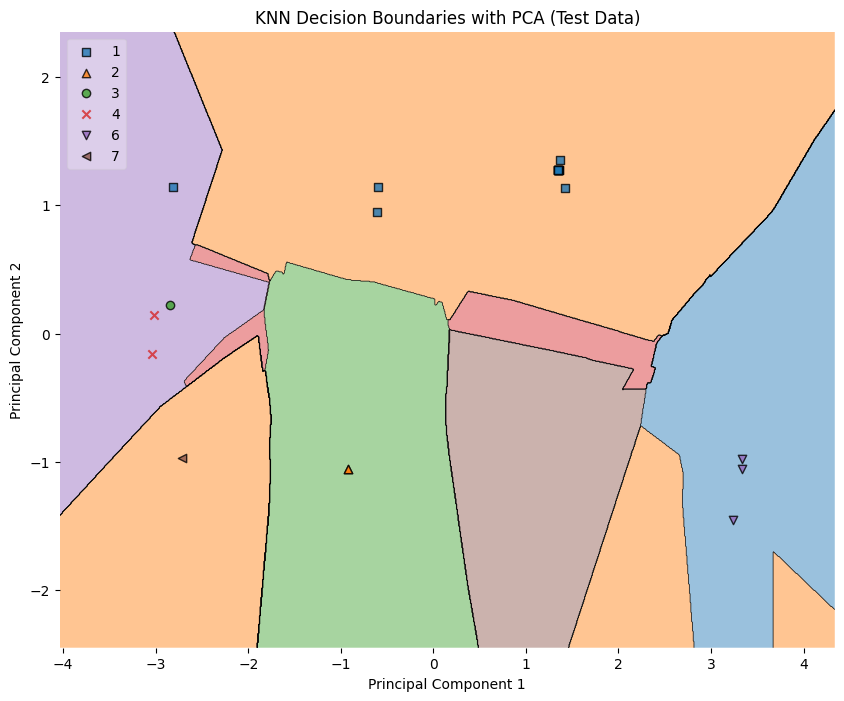

In [50]:
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions


pca = PCA(n_components=2, random_state=42)


x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()


knn_model_pca = KNeighborsClassifier(n_neighbors=5)
knn_model_pca.fit(x_train_pca, y_train_np)

# Plotting decision regions for training data
plt.figure(figsize=(10, 8))
plot_decision_regions(X=x_train_pca, y=y_train_np, clf=knn_model_pca, legend=2)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KNN Decision Boundaries with PCA (Training Data)')
plt.show()

# Plotting decision regions for test data
plt.figure(figsize=(10, 8))
plot_decision_regions(X=x_test_pca, y=y_test_np, clf=knn_model_pca, legend=2)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KNN Decision Boundaries with PCA (Test Data)')
plt.show()

# Interview Questions:

**1. What are the key hyperparameters in KNN?**
Machine learning algorithms have hyperparameters that allow you to tailor the behavior of the algorithm to your specific dataset. Hyperparameters Tuning can improve model performance by about 20% to a range of 77% for all evaluation matrices. Hyperparameter tuning in k-nearest neighbors (KNN) is important because it allows us to optimize the performance of the model




**2. What distance metrics can be used in KNN?**

1 Euclidean distance

2 Manhattan distance

3 Minkowski distance

4 Cosine similarity

 there is no one-size-fits-all solution. However, you can use some general guidelines to help you make the best choice. Analyzing your data and understanding the type, scale, range, and distribution of your features is essential. Experimenting with different distance metrics and comparing their results and performance on your data and problem is also key. Cross-validation and other evaluation methods can help measure the accuracy and quality of your KNN algorithm with different distance metrics.